# BQR-DN V2.1 training on VOC2007

Trains `bqr_dn_v2_1`: BQR-DN V2 with content-aware attention over the 16 noisy-box sampled encoder features. The normal DINO detection and inference paths are unchanged.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch
from gt_guided_dino.api import ExperimentConfig, train
from gt_guided_dino.visualization import plot_history

print('torch:', torch.__version__, 'cuda:', torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

d:\BQR_DETR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.12.1+cu126 cuda: True
NVIDIA GeForce RTX 3060


In [2]:
config = ExperimentConfig(
    data_root=PROJECT_ROOT / 'VOC2007',
    output_root=PROJECT_ROOT / 'artifacts',
    method='bqr_dn_v2_1',
    epochs=12,
    train_limit=1000,
    lr_drop_epoch=11,
    bqr_enabled=True,
    bqr_dn_weight=1.0,
    bqr_points_per_level=4,
    bqr_gate_bias=-2.0,
    bqr_content_attention=True,
    bqr_attention_dim=64,
    bqr_content_scale_init=0.05,
    bqr_attention_temperature=1.0,
)
config

ExperimentConfig(data_root=WindowsPath('D:/BQR_DETR/VOC2007'), output_root=WindowsPath('D:/BQR_DETR/artifacts'), torch_cache=WindowsPath('D:/BQR_DETR/weights/torch'), method='bqr_dn_v2_1', seed=42, train_limit=1000, val_limit=None, epochs=12, batch_size=1, accumulation_steps=4, num_workers=0, precision='fp16', lr=0.0001, backbone_lr=1e-05, weight_decay=0.0001, grad_clip=0.1, lr_drop_epoch=11, lr_drop_gamma=0.1, save_every=1, num_queries=900, hidden_dim=256, enc_layers=6, dec_layers=6, dim_feedforward=2048, num_feature_levels=4, dn_number=100, train_scales=(480, 512, 544, 576, 608, 640, 672, 704, 736, 768, 800), train_max_size=1333, crop_resize_scales=(400, 500, 600), crop_min_size=384, crop_max_size=600, use_random_crop=True, val_size=800, val_max_size=1333, aux_weight=1.0, aux_l1_coef=5.0, aux_giou_coef=2.0, sampling_points_per_level=4, bqr_enabled=True, bqr_dn_weight=1.0, bqr_points_per_level=4, bqr_gate_bias=-2.0, bqr_content_attention=True, bqr_attention_dim=64, bqr_content_scale_i

In [3]:
# Resumes artifacts/bqr_dn_v2_1/seed_42/checkpoints/latest.pt when present.
history = train(config, resume=True)
history[-1]

epoch=01 loss=40.3533 lr=1.00e-04 seconds=725.0


epoch=02 loss=27.3961 lr=1.00e-04 seconds=705.0


epoch=03 loss=22.5552 lr=1.00e-04 seconds=659.0


epoch=04 loss=20.3318 lr=1.00e-04 seconds=685.6


epoch=05 loss=18.2934 lr=1.00e-04 seconds=656.9


...

epoch=09 loss=14.3834 lr=1.00e-04 seconds=636.4


epoch=10 loss=13.9835 lr=1.00e-04 seconds=659.2


epoch=11 loss=13.2500 lr=1.00e-04 seconds=663.3


epoch=12 loss=11.7123 lr=1.00e-05 seconds=661.0


{'epoch': 12,
 'lr': 1e-05,
 'loss': 11.712268873363733,
 'batches': 1000,
 'optimizer_steps': 250,
 'seconds': 660.9745937000116,
 'peak_cuda_mb': 11349.0556640625,
 'loss_ce': 0.2956408754680306,
 'loss_bbox': 0.06170632127299905,
 'loss_giou': 0.13712638864666224,
 'loss_ce_dn': 0.057767352423048576,
 'loss_bbox_dn': 0.07413812014367431,
 'loss_giou_dn': 0.13963405748549848,
 'bqr_valid_queries': 198.458,
 'bqr_gate_mean': 0.8732393825948238,
 'bqr_offset_abs_mean': 0.1857062536329031,
 'bqr_attention_entropy': 2.4101935546398163,
 'bqr_region_norm': 12.739818771362305,
 'bqr_fusion_delta_norm': 9.721492804408074,
 'bqr_content_scale': 0.05117375677078962,
 'bqr_prior_entropy': 2.419410355091095,
 'bqr_final_entropy': 2.4101935546398163,
 'bqr_content_logit_std': 1.5647640305757522,
 'bqr_top1_attention': 0.1584838672876358,
 'weighted_ce_total': 2.8963287208350375,
 'weighted_bbox_total': 4.864656366795302,
 'weighted_giou_total': 3.9512838036864997,
 'bqr_small_queries': 822.0,
 '

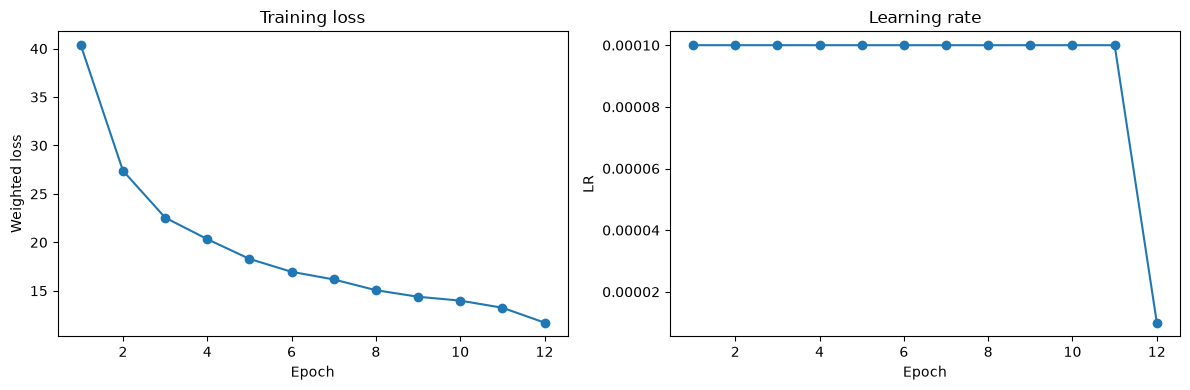

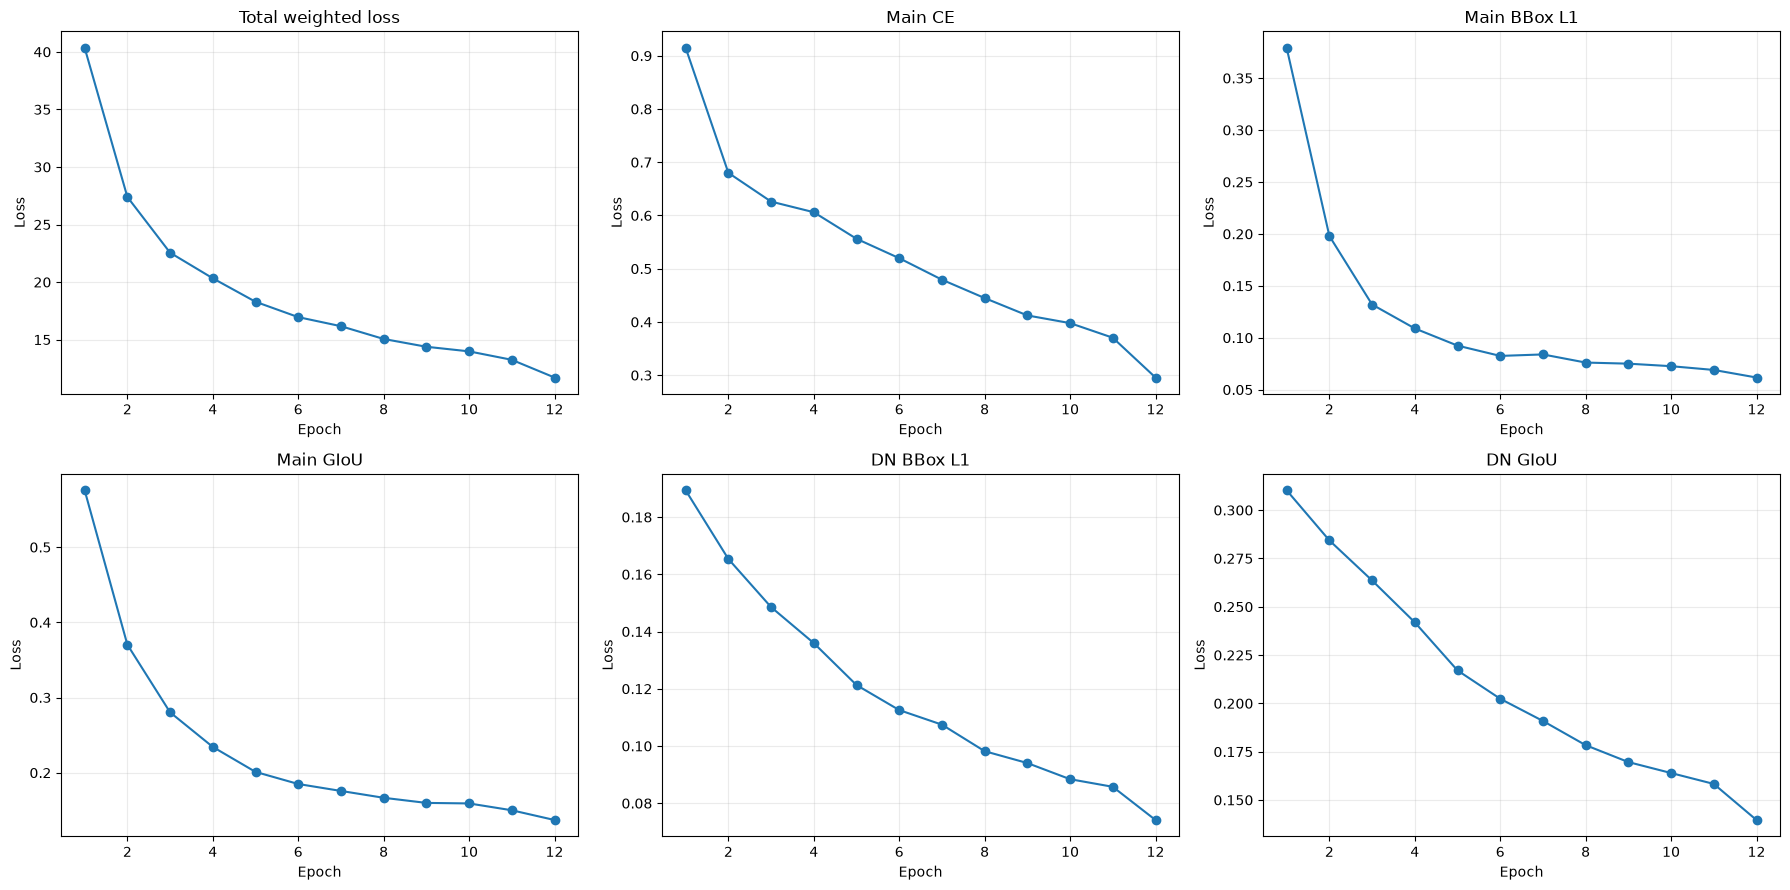

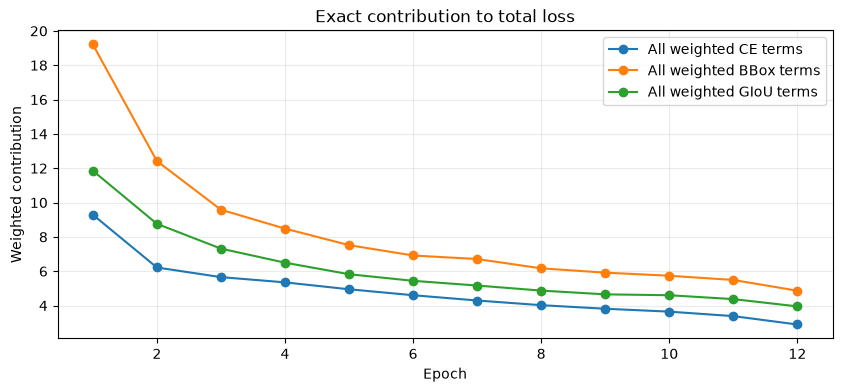

In [4]:
plot_history(config.history_path);

epochs = [row['epoch'] for row in history]
figure, axes = plt.subplots(2, 3, figsize=(18, 9))
for axis, key, title in (
    (axes[0, 0], 'loss', 'Total weighted loss'),
    (axes[0, 1], 'loss_ce', 'Main CE'),
    (axes[0, 2], 'loss_bbox', 'Main BBox L1'),
    (axes[1, 0], 'loss_giou', 'Main GIoU'),
    (axes[1, 1], 'loss_bbox_dn', 'DN BBox L1'),
    (axes[1, 2], 'loss_giou_dn', 'DN GIoU'),
):
    axis.plot(epochs, [row.get(key, np.nan) for row in history], marker='o')
    axis.set(title=title, xlabel='Epoch', ylabel='Loss')
    axis.grid(alpha=0.25)
figure.tight_layout()

figure, axis = plt.subplots(figsize=(10, 4))
for key, label in (
    ('weighted_ce_total', 'All weighted CE terms'),
    ('weighted_bbox_total', 'All weighted BBox terms'),
    ('weighted_giou_total', 'All weighted GIoU terms'),
):
    axis.plot(epochs, [row.get(key, np.nan) for row in history], marker='o', label=label)
axis.set(title='Exact contribution to total loss', xlabel='Epoch', ylabel='Weighted contribution')
axis.grid(alpha=0.25)
axis.legend();

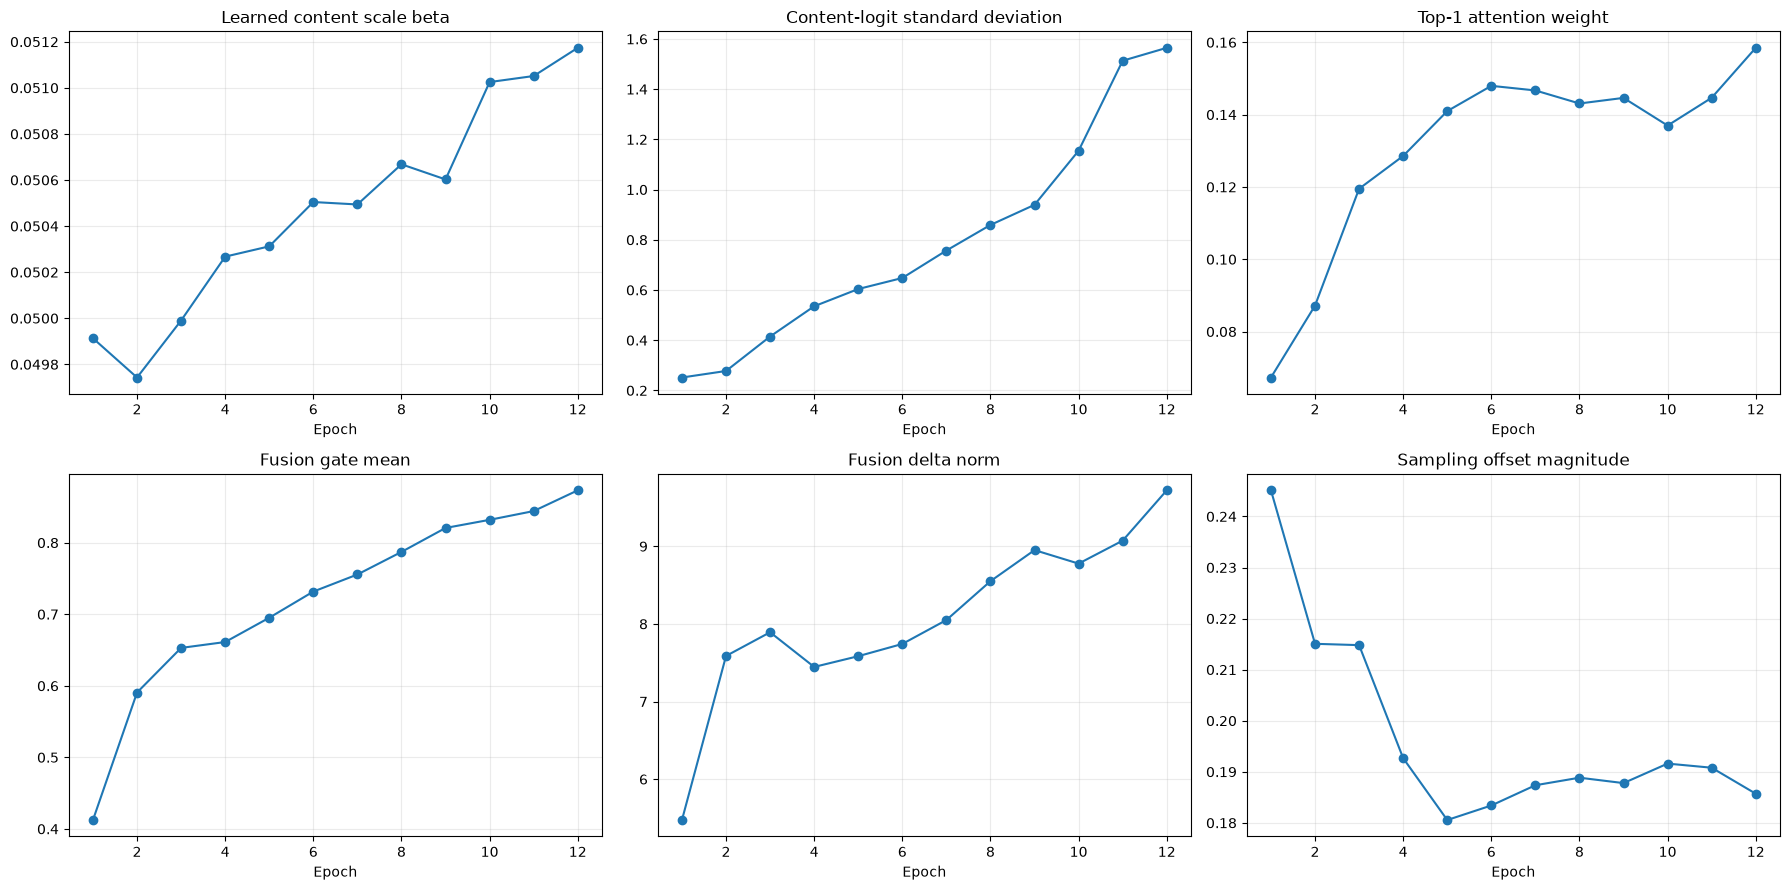

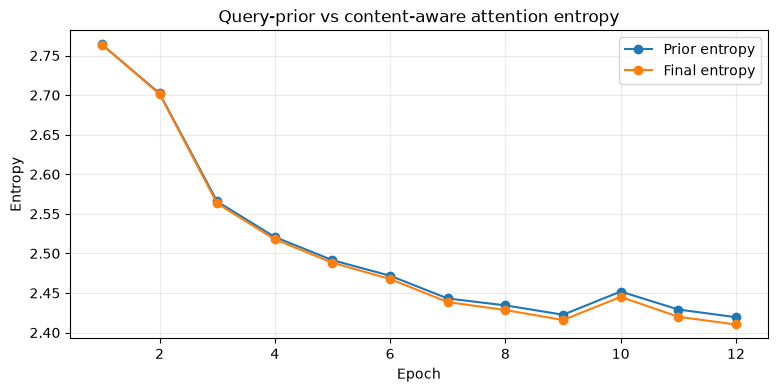

In [5]:
figure, axes = plt.subplots(2, 3, figsize=(18, 9))
for axis, key, title in (
    (axes[0, 0], 'bqr_content_scale', 'Learned content scale beta'),
    (axes[0, 1], 'bqr_content_logit_std', 'Content-logit standard deviation'),
    (axes[0, 2], 'bqr_top1_attention', 'Top-1 attention weight'),
    (axes[1, 0], 'bqr_gate_mean', 'Fusion gate mean'),
    (axes[1, 1], 'bqr_fusion_delta_norm', 'Fusion delta norm'),
    (axes[1, 2], 'bqr_offset_abs_mean', 'Sampling offset magnitude'),
):
    axis.plot(epochs, [row.get(key, np.nan) for row in history], marker='o')
    axis.set(title=title, xlabel='Epoch')
    axis.grid(alpha=0.25)
figure.tight_layout()

figure, axis = plt.subplots(figsize=(9, 4))
axis.plot(epochs, [row.get('bqr_prior_entropy', np.nan) for row in history], marker='o', label='Prior entropy')
axis.plot(epochs, [row.get('bqr_final_entropy', np.nan) for row in history], marker='o', label='Final entropy')
axis.set(title='Query-prior vs content-aware attention entropy', xlabel='Epoch', ylabel='Entropy')
axis.grid(alpha=0.25)
axis.legend();

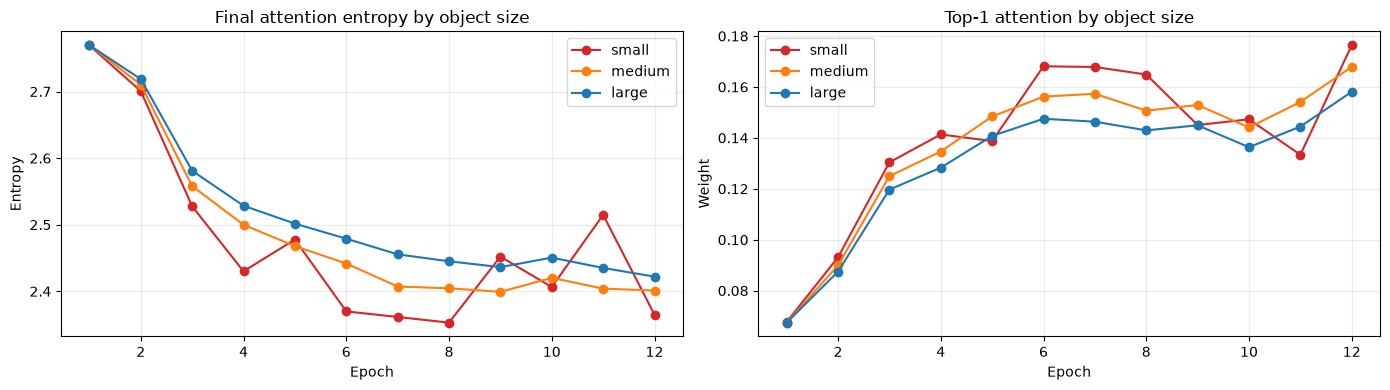

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(14, 4))
for size_name, color in (('small', 'tab:red'), ('medium', 'tab:orange'), ('large', 'tab:blue')):
    axes[0].plot(epochs, [row.get(f'bqr_{size_name}_final_entropy', np.nan) for row in history], marker='o', label=size_name, color=color)
    axes[1].plot(epochs, [row.get(f'bqr_{size_name}_top1_attention', np.nan) for row in history], marker='o', label=size_name, color=color)
axes[0].set(title='Final attention entropy by object size', xlabel='Epoch', ylabel='Entropy')
axes[1].set(title='Top-1 attention by object size', xlabel='Epoch', ylabel='Weight')
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
figure.tight_layout()